# 挂载谷歌硬盘，上传数据

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 安装文泉驿微米黑字体（Ubuntu/Debian 系统）
!apt-get update
!apt-get install -y fonts-wqy-microhei

# 清除 matplotlib 字体缓存
!rm -rf /root/.cache/matplotlib


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,533 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:13 https://ppa.launchpadcontent.net/ubuntu

In [ ]:
import matplotlib as mpl
import matplotlib.font_manager as fm

print("=== 字体搜索路径 ===")
print(mpl.get_data_path() + '/fonts/ttf/')
print("\n=== 可能支持中文的字体 ===")
chinese_fonts = set()
for font in fm.fontManager.ttflist:
    if any(keyword in font.name.lower() for keyword in ['cjk', 'chinese', 'sc', 'noto', 'wenquanyi', 'simhei', 'msyh']):
        chinese_fonts.add(font.name)
for font_name in sorted(chinese_fonts)[:10]:
    print(font_name)

=== 字体搜索路径 ===
/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/

=== 可能支持中文的字体 ===


# 数据加载与合并

In [ ]:
# ================== 单元格1：加载并合并所有数据，保存为 all_sentences_raw.csv ==================
import pandas as pd
import json
import re

# 1. 微博 CSV 数据
df_weibo = pd.read_csv("/content/drive/MyDrive/NLP code/神圣/weibo_shensheng.csv")
df_weibo = df_weibo[['sentence']].copy()
df_weibo['source'] = 'weibo'
print(f"微博数据量：{len(df_weibo)}")

# 2. B站视频 JSONL
bili_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                bili_video_texts.append(text)
        except:
            continue
df_bili_video = pd.DataFrame(bili_video_texts, columns=['sentence'])
df_bili_video['source'] = 'bilibili_video'
print(f"B站视频数据量：{len(df_bili_video)}")

# 3. B站评论 JSONL
bili_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                bili_comment_texts.append(content)
        except:
            continue
df_bili_comment = pd.DataFrame(bili_comment_texts, columns=['sentence'])
df_bili_comment['source'] = 'bilibili_comment'
print(f"B站评论数据量：{len(df_bili_comment)}")

# 4. 抖音视频 JSONL
dy_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                dy_video_texts.append(text)
        except:
            continue
df_dy_video = pd.DataFrame(dy_video_texts, columns=['sentence'])
df_dy_video['source'] = 'dy_video'
print(f"抖音视频数据量：{len(df_dy_video)}")

# 5. 抖音评论 JSONL
dy_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                dy_comment_texts.append(content)
        except:
            continue
df_dy_comment = pd.DataFrame(dy_comment_texts, columns=['sentence'])
df_dy_comment['source'] = 'dy_comment'
print(f"抖音评论数据量：{len(df_dy_comment)}")

# 6. 小红书文本 JSONL
xhs_cont_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                xhs_cont_texts.append(text)
        except:
            continue
df_xhs_cont = pd.DataFrame(xhs_cont_texts, columns=['sentence'])
df_xhs_cont['source'] = 'xhs_cont'
print(f"小红书视频数据量：{len(df_xhs_cont)}")

# 7. 小红书评论 JSONL
xhs_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                xhs_comment_texts.append(content)
        except:
            continue
df_xhs_comment = pd.DataFrame(xhs_comment_texts, columns=['sentence'])
df_xhs_comment['source'] = 'xhs_comment'
print(f"小红书评论数据量：{len(df_xhs_comment)}")



# 4. 合并并保存
df_all = pd.concat([df_weibo, df_bili_video, df_bili_comment, df_dy_video, df_dy_comment, df_xhs_cont, df_xhs_comment], ignore_index=True)
print(f"合并后总数据量：{len(df_all)}")
df_all.to_csv("/content/drive/MyDrive/NLP code/神圣/All sourcecsv.csv",encoding= 'utf-8-sig', index=False)
print("已保存整合数据至 all_sentences_raw.csv")

微博数据量：170
B站视频数据量：170
B站评论数据量：19
抖音视频数据量：76
抖音评论数据量：16
小红书视频数据量：235
小红书评论数据量：32
合并后总数据量：718
已保存整合数据至 all_sentences_raw.csv


In [ ]:
# ================== 单元格1：加载并合并所有数据，保存为 all_sentences_raw.csv ==================
import pandas as pd
import json
import re

# 1. 微博 CSV 数据
df_weibo = pd.read_csv("/content/drive/MyDrive/NLP code/神圣/weibo_shensheng.csv")
df_weibo = df_weibo[['sentence']].copy()
df_weibo['source'] = 'weibo'
print(f"微博数据量：{len(df_weibo)}")

# 2. B站视频 JSONL
bili_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                bili_video_texts.append(text)
        except:
            continue
df_bili_video = pd.DataFrame(bili_video_texts, columns=['sentence'])
df_bili_video['source'] = 'bilibili_video'
print(f"B站视频数据量：{len(df_bili_video)}")

# 3. B站评论 JSONL
bili_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                bili_comment_texts.append(content)
        except:
            continue
df_bili_comment = pd.DataFrame(bili_comment_texts, columns=['sentence'])
df_bili_comment['source'] = 'bilibili_comment'
print(f"B站评论数据量：{len(df_bili_comment)}")

# 4. 抖音视频 JSONL
dy_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                dy_video_texts.append(text)
        except:
            continue
df_dy_video = pd.DataFrame(dy_video_texts, columns=['sentence'])
df_dy_video['source'] = 'dy_video'
print(f"抖音视频数据量：{len(df_dy_video)}")

# 5. 抖音评论 JSONL
dy_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                dy_comment_texts.append(content)
        except:
            continue
df_dy_comment = pd.DataFrame(dy_comment_texts, columns=['sentence'])
df_dy_comment['source'] = 'dy_comment'
print(f"抖音评论数据量：{len(df_dy_comment)}")

# 6. 小红书文本 JSONL
xhs_cont_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                xhs_cont_texts.append(text)
        except:
            continue
df_xhs_cont = pd.DataFrame(xhs_cont_texts, columns=['sentence'])
df_xhs_cont['source'] = 'xhs_cont'
print(f"小红书视频数据量：{len(df_xhs_cont)}")

# 7. 小红书评论 JSONL
xhs_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                xhs_comment_texts.append(content)
        except:
            continue
df_xhs_comment = pd.DataFrame(xhs_comment_texts, columns=['sentence'])
df_xhs_comment['source'] = 'xhs_comment'
print(f"小红书评论数据量：{len(df_xhs_comment)}")



# 4. 合并并保存
df_all = pd.concat([df_weibo, df_bili_video, df_bili_comment, df_dy_video, df_dy_comment, df_xhs_cont, df_xhs_comment], ignore_index=True)
print(f"合并后总数据量：{len(df_all)}")
df_all.to_csv("/content/drive/MyDrive/NLP code/神圣/All sourcecsv.csv",encoding= 'utf-8-sig', index=False)
print("已保存整合数据至 all_sentences_raw.csv")

微博数据量：170
B站视频数据量：170
B站评论数据量：19
抖音视频数据量：76
抖音评论数据量：16
小红书视频数据量：235
小红书评论数据量：32
合并后总数据量：718
已保存整合数据至 all_sentences_raw.csv


In [ ]:
# ================== 单元格1：加载并合并所有数据，保存为 all_sentences_raw.csv ==================
import pandas as pd
import json
import re

# 1. 微博 CSV 数据
df_weibo = pd.read_csv("/content/drive/MyDrive/NLP code/神圣/weibo_shensheng.csv")
df_weibo = df_weibo[['sentence']].copy()
df_weibo['source'] = 'weibo'
print(f"微博数据量：{len(df_weibo)}")

# 2. B站视频 JSONL
bili_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                bili_video_texts.append(text)
        except:
            continue
df_bili_video = pd.DataFrame(bili_video_texts, columns=['sentence'])
df_bili_video['source'] = 'bilibili_video'
print(f"B站视频数据量：{len(df_bili_video)}")

# 3. B站评论 JSONL
bili_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                bili_comment_texts.append(content)
        except:
            continue
df_bili_comment = pd.DataFrame(bili_comment_texts, columns=['sentence'])
df_bili_comment['source'] = 'bilibili_comment'
print(f"B站评论数据量：{len(df_bili_comment)}")

# 4. 抖音视频 JSONL
dy_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                dy_video_texts.append(text)
        except:
            continue
df_dy_video = pd.DataFrame(dy_video_texts, columns=['sentence'])
df_dy_video['source'] = 'dy_video'
print(f"抖音视频数据量：{len(df_dy_video)}")

# 5. 抖音评论 JSONL
dy_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                dy_comment_texts.append(content)
        except:
            continue
df_dy_comment = pd.DataFrame(dy_comment_texts, columns=['sentence'])
df_dy_comment['source'] = 'dy_comment'
print(f"抖音评论数据量：{len(df_dy_comment)}")

# 6. 小红书文本 JSONL
xhs_cont_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                xhs_cont_texts.append(text)
        except:
            continue
df_xhs_cont = pd.DataFrame(xhs_cont_texts, columns=['sentence'])
df_xhs_cont['source'] = 'xhs_cont'
print(f"小红书视频数据量：{len(df_xhs_cont)}")

# 7. 小红书评论 JSONL
xhs_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                xhs_comment_texts.append(content)
        except:
            continue
df_xhs_comment = pd.DataFrame(xhs_comment_texts, columns=['sentence'])
df_xhs_comment['source'] = 'xhs_comment'
print(f"小红书评论数据量：{len(df_xhs_comment)}")



# 4. 合并并保存
df_all = pd.concat([df_weibo, df_bili_video, df_bili_comment, df_dy_video, df_dy_comment, df_xhs_cont, df_xhs_comment], ignore_index=True)
print(f"合并后总数据量：{len(df_all)}")
df_all.to_csv("/content/drive/MyDrive/NLP code/神圣/All sourcecsv.csv",encoding= 'utf-8-sig', index=False)
print("已保存整合数据至 all_sentences_raw.csv")

微博数据量：170
B站视频数据量：170
B站评论数据量：19
抖音视频数据量：76
抖音评论数据量：16
小红书视频数据量：235
小红书评论数据量：32
合并后总数据量：718
已保存整合数据至 all_sentences_raw.csv


In [ ]:
# ================== 单元格1：加载并合并所有数据，保存为 all_sentences_raw.csv ==================
import pandas as pd
import json
import re

# 1. 微博 CSV 数据
df_weibo = pd.read_csv("/content/drive/MyDrive/NLP code/神圣/weibo_shensheng.csv")
df_weibo = df_weibo[['sentence']].copy()
df_weibo['source'] = 'weibo'
print(f"微博数据量：{len(df_weibo)}")

# 2. B站视频 JSONL
bili_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                bili_video_texts.append(text)
        except:
            continue
df_bili_video = pd.DataFrame(bili_video_texts, columns=['sentence'])
df_bili_video['source'] = 'bilibili_video'
print(f"B站视频数据量：{len(df_bili_video)}")

# 3. B站评论 JSONL
bili_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                bili_comment_texts.append(content)
        except:
            continue
df_bili_comment = pd.DataFrame(bili_comment_texts, columns=['sentence'])
df_bili_comment['source'] = 'bilibili_comment'
print(f"B站评论数据量：{len(df_bili_comment)}")

# 4. 抖音视频 JSONL
dy_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                dy_video_texts.append(text)
        except:
            continue
df_dy_video = pd.DataFrame(dy_video_texts, columns=['sentence'])
df_dy_video['source'] = 'dy_video'
print(f"抖音视频数据量：{len(df_dy_video)}")

# 5. 抖音评论 JSONL
dy_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                dy_comment_texts.append(content)
        except:
            continue
df_dy_comment = pd.DataFrame(dy_comment_texts, columns=['sentence'])
df_dy_comment['source'] = 'dy_comment'
print(f"抖音评论数据量：{len(df_dy_comment)}")

# 6. 小红书文本 JSONL
xhs_cont_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                xhs_cont_texts.append(text)
        except:
            continue
df_xhs_cont = pd.DataFrame(xhs_cont_texts, columns=['sentence'])
df_xhs_cont['source'] = 'xhs_cont'
print(f"小红书视频数据量：{len(df_xhs_cont)}")

# 7. 小红书评论 JSONL
xhs_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                xhs_comment_texts.append(content)
        except:
            continue
df_xhs_comment = pd.DataFrame(xhs_comment_texts, columns=['sentence'])
df_xhs_comment['source'] = 'xhs_comment'
print(f"小红书评论数据量：{len(df_xhs_comment)}")



# 4. 合并并保存
df_all = pd.concat([df_weibo, df_bili_video, df_bili_comment, df_dy_video, df_dy_comment, df_xhs_cont, df_xhs_comment], ignore_index=True)
print(f"合并后总数据量：{len(df_all)}")
df_all.to_csv("/content/drive/MyDrive/NLP code/神圣/All sourcecsv.csv",encoding= 'utf-8-sig', index=False)
print("已保存整合数据至 all_sentences_raw.csv")

微博数据量：170
B站视频数据量：170
B站评论数据量：19
抖音视频数据量：76
抖音评论数据量：16
小红书视频数据量：235
小红书评论数据量：32
合并后总数据量：718
已保存整合数据至 all_sentences_raw.csv


In [ ]:
# ================== 单元格1：加载并合并所有数据，保存为 all_sentences_raw.csv ==================
import pandas as pd
import json
import re

# 1. 微博 CSV 数据
df_weibo = pd.read_csv("/content/drive/MyDrive/NLP code/神圣/weibo_shensheng.csv")
df_weibo = df_weibo[['sentence']].copy()
df_weibo['source'] = 'weibo'
print(f"微博数据量：{len(df_weibo)}")

# 2. B站视频 JSONL
bili_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                bili_video_texts.append(text)
        except:
            continue
df_bili_video = pd.DataFrame(bili_video_texts, columns=['sentence'])
df_bili_video['source'] = 'bilibili_video'
print(f"B站视频数据量：{len(df_bili_video)}")

# 3. B站评论 JSONL
bili_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                bili_comment_texts.append(content)
        except:
            continue
df_bili_comment = pd.DataFrame(bili_comment_texts, columns=['sentence'])
df_bili_comment['source'] = 'bilibili_comment'
print(f"B站评论数据量：{len(df_bili_comment)}")

# 4. 抖音视频 JSONL
dy_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                dy_video_texts.append(text)
        except:
            continue
df_dy_video = pd.DataFrame(dy_video_texts, columns=['sentence'])
df_dy_video['source'] = 'dy_video'
print(f"抖音视频数据量：{len(df_dy_video)}")

# 5. 抖音评论 JSONL
dy_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                dy_comment_texts.append(content)
        except:
            continue
df_dy_comment = pd.DataFrame(dy_comment_texts, columns=['sentence'])
df_dy_comment['source'] = 'dy_comment'
print(f"抖音评论数据量：{len(df_dy_comment)}")

# 6. 小红书文本 JSONL
xhs_cont_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                xhs_cont_texts.append(text)
        except:
            continue
df_xhs_cont = pd.DataFrame(xhs_cont_texts, columns=['sentence'])
df_xhs_cont['source'] = 'xhs_cont'
print(f"小红书视频数据量：{len(df_xhs_cont)}")

# 7. 小红书评论 JSONL
xhs_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                xhs_comment_texts.append(content)
        except:
            continue
df_xhs_comment = pd.DataFrame(xhs_comment_texts, columns=['sentence'])
df_xhs_comment['source'] = 'xhs_comment'
print(f"小红书评论数据量：{len(df_xhs_comment)}")



# 4. 合并并保存
df_all = pd.concat([df_weibo, df_bili_video, df_bili_comment, df_dy_video, df_dy_comment, df_xhs_cont, df_xhs_comment], ignore_index=True)
print(f"合并后总数据量：{len(df_all)}")
df_all.to_csv("/content/drive/MyDrive/NLP code/神圣/All sourcecsv.csv",encoding= 'utf-8-sig', index=False)
print("已保存整合数据至 all_sentences_raw.csv")

微博数据量：170
B站视频数据量：170
B站评论数据量：19
抖音视频数据量：76
抖音评论数据量：16
小红书视频数据量：235
小红书评论数据量：32
合并后总数据量：718
已保存整合数据至 all_sentences_raw.csv


In [ ]:
# ================== 单元格1：加载并合并所有数据，保存为 all_sentences_raw.csv ==================
import pandas as pd
import json
import re

# 1. 微博 CSV 数据
df_weibo = pd.read_csv("/content/drive/MyDrive/NLP code/神圣/weibo_shensheng.csv")
df_weibo = df_weibo[['sentence']].copy()
df_weibo['source'] = 'weibo'
print(f"微博数据量：{len(df_weibo)}")

# 2. B站视频 JSONL
bili_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                bili_video_texts.append(text)
        except:
            continue
df_bili_video = pd.DataFrame(bili_video_texts, columns=['sentence'])
df_bili_video['source'] = 'bilibili_video'
print(f"B站视频数据量：{len(df_bili_video)}")

# 3. B站评论 JSONL
bili_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                bili_comment_texts.append(content)
        except:
            continue
df_bili_comment = pd.DataFrame(bili_comment_texts, columns=['sentence'])
df_bili_comment['source'] = 'bilibili_comment'
print(f"B站评论数据量：{len(df_bili_comment)}")

# 4. 抖音视频 JSONL
dy_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                dy_video_texts.append(text)
        except:
            continue
df_dy_video = pd.DataFrame(dy_video_texts, columns=['sentence'])
df_dy_video['source'] = 'dy_video'
print(f"抖音视频数据量：{len(df_dy_video)}")

# 5. 抖音评论 JSONL
dy_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                dy_comment_texts.append(content)
        except:
            continue
df_dy_comment = pd.DataFrame(dy_comment_texts, columns=['sentence'])
df_dy_comment['source'] = 'dy_comment'
print(f"抖音评论数据量：{len(df_dy_comment)}")

# 6. 小红书文本 JSONL
xhs_cont_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                xhs_cont_texts.append(text)
        except:
            continue
df_xhs_cont = pd.DataFrame(xhs_cont_texts, columns=['sentence'])
df_xhs_cont['source'] = 'xhs_cont'
print(f"小红书视频数据量：{len(df_xhs_cont)}")

# 7. 小红书评论 JSONL
xhs_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                xhs_comment_texts.append(content)
        except:
            continue
df_xhs_comment = pd.DataFrame(xhs_comment_texts, columns=['sentence'])
df_xhs_comment['source'] = 'xhs_comment'
print(f"小红书评论数据量：{len(df_xhs_comment)}")



# 4. 合并并保存
df_all = pd.concat([df_weibo, df_bili_video, df_bili_comment, df_dy_video, df_dy_comment, df_xhs_cont, df_xhs_comment], ignore_index=True)
print(f"合并后总数据量：{len(df_all)}")
df_all.to_csv("/content/drive/MyDrive/NLP code/神圣/All sourcecsv.csv",encoding= 'utf-8-sig', index=False)
print("已保存整合数据至 all_sentences_raw.csv")

微博数据量：170
B站视频数据量：170
B站评论数据量：19
抖音视频数据量：76
抖音评论数据量：16
小红书视频数据量：235
小红书评论数据量：32
合并后总数据量：718
已保存整合数据至 all_sentences_raw.csv


In [ ]:
# ================== 单元格1：加载并合并所有数据，保存为 all_sentences_raw.csv ==================
import pandas as pd
import json
import re

# 1. 微博 CSV 数据
df_weibo = pd.read_csv("/content/drive/MyDrive/NLP code/神圣/weibo_shensheng.csv")
df_weibo = df_weibo[['sentence']].copy()
df_weibo['source'] = 'weibo'
print(f"微博数据量：{len(df_weibo)}")

# 2. B站视频 JSONL
bili_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                bili_video_texts.append(text)
        except:
            continue
df_bili_video = pd.DataFrame(bili_video_texts, columns=['sentence'])
df_bili_video['source'] = 'bilibili_video'
print(f"B站视频数据量：{len(df_bili_video)}")

# 3. B站评论 JSONL
bili_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                bili_comment_texts.append(content)
        except:
            continue
df_bili_comment = pd.DataFrame(bili_comment_texts, columns=['sentence'])
df_bili_comment['source'] = 'bilibili_comment'
print(f"B站评论数据量：{len(df_bili_comment)}")

# 4. 抖音视频 JSONL
dy_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                dy_video_texts.append(text)
        except:
            continue
df_dy_video = pd.DataFrame(dy_video_texts, columns=['sentence'])
df_dy_video['source'] = 'dy_video'
print(f"抖音视频数据量：{len(df_dy_video)}")

# 5. 抖音评论 JSONL
dy_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                dy_comment_texts.append(content)
        except:
            continue
df_dy_comment = pd.DataFrame(dy_comment_texts, columns=['sentence'])
df_dy_comment['source'] = 'dy_comment'
print(f"抖音评论数据量：{len(df_dy_comment)}")

# 6. 小红书文本 JSONL
xhs_cont_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                xhs_cont_texts.append(text)
        except:
            continue
df_xhs_cont = pd.DataFrame(xhs_cont_texts, columns=['sentence'])
df_xhs_cont['source'] = 'xhs_cont'
print(f"小红书视频数据量：{len(df_xhs_cont)}")

# 7. 小红书评论 JSONL
xhs_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                xhs_comment_texts.append(content)
        except:
            continue
df_xhs_comment = pd.DataFrame(xhs_comment_texts, columns=['sentence'])
df_xhs_comment['source'] = 'xhs_comment'
print(f"小红书评论数据量：{len(df_xhs_comment)}")



# 4. 合并并保存
df_all = pd.concat([df_weibo, df_bili_video, df_bili_comment, df_dy_video, df_dy_comment, df_xhs_cont, df_xhs_comment], ignore_index=True)
print(f"合并后总数据量：{len(df_all)}")
df_all.to_csv("/content/drive/MyDrive/NLP code/神圣/All sourcecsv.csv",encoding= 'utf-8-sig', index=False)
print("已保存整合数据至 all_sentences_raw.csv")

微博数据量：170
B站视频数据量：170
B站评论数据量：19
抖音视频数据量：76
抖音评论数据量：16
小红书视频数据量：235
小红书评论数据量：32
合并后总数据量：718
已保存整合数据至 all_sentences_raw.csv


In [ ]:
# ================== 单元格1：加载并合并所有数据，保存为 all_sentences_raw.csv ==================
import pandas as pd
import json
import re

# 1. 微博 CSV 数据
df_weibo = pd.read_csv("/content/drive/MyDrive/NLP code/神圣/weibo_shensheng.csv")
df_weibo = df_weibo[['sentence']].copy()
df_weibo['source'] = 'weibo'
print(f"微博数据量：{len(df_weibo)}")

# 2. B站视频 JSONL
bili_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                bili_video_texts.append(text)
        except:
            continue
df_bili_video = pd.DataFrame(bili_video_texts, columns=['sentence'])
df_bili_video['source'] = 'bilibili_video'
print(f"B站视频数据量：{len(df_bili_video)}")

# 3. B站评论 JSONL
bili_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/bili_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                bili_comment_texts.append(content)
        except:
            continue
df_bili_comment = pd.DataFrame(bili_comment_texts, columns=['sentence'])
df_bili_comment['source'] = 'bilibili_comment'
print(f"B站评论数据量：{len(df_bili_comment)}")

# 4. 抖音视频 JSONL
dy_video_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                dy_video_texts.append(text)
        except:
            continue
df_dy_video = pd.DataFrame(dy_video_texts, columns=['sentence'])
df_dy_video['source'] = 'dy_video'
print(f"抖音视频数据量：{len(df_dy_video)}")

# 5. 抖音评论 JSONL
dy_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/dy_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                dy_comment_texts.append(content)
        except:
            continue
df_dy_comment = pd.DataFrame(dy_comment_texts, columns=['sentence'])
df_dy_comment['source'] = 'dy_comment'
print(f"抖音评论数据量：{len(df_dy_comment)}")

# 6. 小红书文本 JSONL
xhs_cont_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_cont.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '神圣' in text:
                xhs_cont_texts.append(text)
        except:
            continue
df_xhs_cont = pd.DataFrame(xhs_cont_texts, columns=['sentence'])
df_xhs_cont['source'] = 'xhs_cont'
print(f"小红书视频数据量：{len(df_xhs_cont)}")

# 7. 小红书评论 JSONL
xhs_comment_texts = []
with open("/content/drive/MyDrive/NLP code/神圣/xhs_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '神圣' in content:
                xhs_comment_texts.append(content)
        except:
            continue
df_xhs_comment = pd.DataFrame(xhs_comment_texts, columns=['sentence'])
df_xhs_comment['source'] = 'xhs_comment'
print(f"小红书评论数据量：{len(df_xhs_comment)}")



# 4. 合并并保存
df_all = pd.concat([df_weibo, df_bili_video, df_bili_comment, df_dy_video, df_dy_comment, df_xhs_cont, df_xhs_comment], ignore_index=True)
print(f"合并后总数据量：{len(df_all)}")
df_all.to_csv("/content/drive/MyDrive/NLP code/神圣/All sourcecsv.csv",encoding= 'utf-8-sig', index=False)
print("已保存整合数据至 all_sentences_raw.csv")

微博数据量：170
B站视频数据量：170
B站评论数据量：19
抖音视频数据量：76
抖音评论数据量：16
小红书视频数据量：235
小红书评论数据量：32
合并后总数据量：718
已保存整合数据至 all_sentences_raw.csv


In [ ]:
# =========================
# 终极版：Colab 数据清洗代码（专治 EmptyDataError / 上传失败）
# =========================

import pandas as pd
import re
import jieba
from google.colab import files

print("📤 请上传你的 CSV 文件...")
uploaded = files.upload()

# 自动获取文件名（绝对稳）
filename = next(iter(uploaded))

# 【修复空文件报错】强制读取，容错拉满
try:
    df = pd.read_csv(filename, encoding="utf-8")
except:
    df = pd.read_csv(filename, encoding="gbk")

print(f"✅ 读取成功！数据行数：{len(df)}")
print(f"📄 列名：{list(df.columns)}")

# ----------------------
# 1. 基础清洗
# ----------------------
# 确保文本列存在（兼容你的列名 sentence / sentence_clean）
text_col = "sentence" if "sentence" in df.columns else "sentence_clean"

df = df.dropna(subset=[text_col])
df = df.drop_duplicates(subset=[text_col])
df = df[df[text_col].astype(str).str.strip().str.len() >= 4]

# ----------------------
# 2. 文本清洗
# ----------------------
def clean_text(text):
    text = str(text).strip()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#.*?#', '', text)
    text = re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9\s，。！？；：,.!?]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df["cleaned_text"] = df[text_col].apply(clean_text)

# ----------------------
# 3. 标记“神圣”
# ----------------------
df["has_sacred"] = df["cleaned_text"].str.contains("神圣").astype(int)

# ----------------------
# 4. 分词
# ----------------------
stop_words = {"的","了","是","在","有","和","就","不","我","你","他","这","那","都","也","很","到","要","去"}

def cut(text):
    words = jieba.lcut(text)
    words = [w for w in words if w not in stop_words and len(w) >= 2]
    return " ".join(words)

df["segmented"] = df["cleaned_text"].apply(cut)

# ----------------------
# 5. 保存并下载
# ----------------------
output = "cleaned_final.csv"
df.to_csv(output, index=False, encoding="utf-8-sig")
print("\n🎉 清洗完成！")
print(f"📊 最终有效数据：{len(df)} 行")

# 自动下载
files.download(output)

📤 请上传你的 CSV 文件...


Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...


Saving All sourcecsv.csv to All sourcecsv.csv
✅ 读取成功！数据行数：718
📄 列名：['sentence', 'source']


Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 1.113 seconds.
DEBUG:jieba:Loading model cost 1.113 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.



🎉 清洗完成！
📊 最终有效数据：638 行


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# 神圣关键词分类模型（修复KeyError，自动识别列名）
import pandas as pd
import numpy as np
import jieba
import random
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# 中文字体
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==============================================
# 1. 读取数据 + 自动找列名（彻底解决 KeyError）
# ==============================================
print("="*60)
print("📊 读取你的 cleaned_final.csv 并自动识别列名")
print("="*60)

# 读取数据
try:
    df = pd.read_csv('/content/drive/MyDrive/NLP code/神圣/cleaned_final.csv', encoding='utf-8-sig')
except:
    df = pd.read_csv('/content/drive/MyDrive/NLP code/神圣/cleaned_final.csv', encoding='gbk')

print(f"✅ 数据列名：{list(df.columns)}")

# 自动找 文本列（找包含 text / sentence / 内容 的列）
text_col = None
for col in df.columns:
    if any(k in col.lower() for k in ['text', 'sentence', '内容', 'cleaned']):
        text_col = col
        break
if text_col is None:
    text_col = df.columns[0]

# 自动找 标签列（找包含 label / 标签 / 标注 的列）
label_col = None
for col in df.columns:
    if any(k in col.lower() for k in ['label', '标签', '标注']):
        label_col = col
        break
if label_col is None:
    label_col = df.columns[1]

print(f"✅ 自动识别：")
print(f"   文本列 = {text_col}")
print(f"   标签列 = {label_col}")

# 清理数据
df = df.dropna(subset=[text_col, label_col])
df = df[df[label_col].isin([0,1,3])]
print(f"✅ 有效数据：{len(df)} 条")
print(f"✅ 标签分布：")
print(df[label_col].value_counts().sort_index())

# ==============================================
# 2. 文本预处理
# ==============================================
stop_words = {'的','了','是','在','有','和','就','不','我','你','他','这','那','都','也','很'}
jieba.add_word("神圣", freq=10000)

def seg(text):
    words = jieba.cut(str(text).strip(), cut_all=False)
    return ' '.join([w for w in words if w not in stop_words and len(w)>=2])

df['seg'] = df[text_col].apply(seg)

# ==============================================
# 3. TF-IDF 特征
# ==============================================
tfidf = TfidfVectorizer(max_features=800, ngram_range=(1,2))
X = tfidf.fit_transform(df['seg']).toarray()
y = df[label_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ==============================================
# 🔥 4. 训练前基准（随机猜）
# ==============================================
labels = sorted(df[label_col].unique())
random_pred = [random.choice(labels) for _ in y_test]
rand_acc = accuracy_score(y_test, random_pred)
rand_f1 = f1_score(y_test, random_pred, average='weighted', zero_division=0)

print("\n" + "="*60)
print("📌 训练前（随机猜测）基准分数")
print("="*60)
print(f"随机准确率：{rand_acc:.4f}")
print(f"随机加权F1：{rand_f1:.4f}")

# ==============================================
# 🔥 5. 训练后模型
# ==============================================
models = {
    "逻辑回归": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "SVM": SVC(kernel='rbf', class_weight='balanced', probability=True),
    "朴素贝叶斯": MultinomialNB(alpha=0.1)
}

best_acc = 0
best_f1 = 0
best_model = None
best_name = ""
best_pred = None

print("\n" + "="*60)
print("🚀 训练后模型效果")
print("="*60)

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='weighted', zero_division=0)

    print(f"\n{name}")
    print(f"准确率：{acc:.4f}")
    print(f"F1分数：{f1:.4f}")
    print(f"相比随机 → 提升：{acc - rand_acc:.4f} 分")

    if acc > best_acc:
        best_acc = acc
        best_f1 = f1
        best_model = model
        best_name = name
        best_pred = pred

# ==============================================
# 🔥 6. 最终提升总结
# ==============================================
print("\n" + "="*60)
print("🏆 最终提升结果")
print("="*60)
print(f"最优模型：{best_name}")
print(f"训练前（随机）：准确率 {rand_acc:.4f} | F1 {rand_f1:.4f}")
print(f"训练后（模型）：准确率 {best_acc:.4f} | F1 {best_f1:.4f}")
print(f"✅ 准确率提升：{(best_acc - rand_acc)*100:.1f} 分")
print(f"✅ F1分数提升：{(best_f1 - rand_f1)*100:.1f} 分")

# ==============================================
# 🔥 7. 可视化：训练前 vs 训练后
# ==============================================
plt.figure(figsize=(12,5))

# 左图：准确率
plt.subplot(1,2,1)
names = ['随机猜测', best_name]
accs = [rand_acc, best_acc]
colors = ['#ff7f7f', '#4fb3ff']
bars = plt.bar(names, accs, color=colors, alpha=0.8)
plt.title('准确率：训练前 vs 训练后', fontsize=13, fontweight='bold')
plt.ylim(0, 1)
for bar, v in zip(bars, accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{v:.4f}', ha='center')

# 右图：F1
plt.subplot(1,2,2)
f1s = [rand_f1, best_f1]
bars2 = plt.bar(names, f1s, color=colors, alpha=0.8)
plt.title('F1分数：训练前 vs 训练后', fontsize=13, fontweight='bold')
plt.ylim(0, 1)
for bar, v in zip(bars2, f1s):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.savefig('/mnt/before_after_compare.png', dpi=300, bbox_inches='tight')
plt.close()

# ==============================================
# 8. 保存模型
# ==============================================
joblib.dump(best_model, '/mnt/best_model.pkl')
joblib.dump(tfidf, '/mnt/tfidf.pkl')
df[[text_col, label_col, 'seg']].to_csv('/mnt/processed_final.csv', index=False, encoding='utf-8-sig')

print("\n🎉 全部完成！")
print("📊 已生成：训练前 vs 训练后 对比图")
print("📁 已保存：模型 + 特征器 + 数据")

📊 读取你的 cleaned_final.csv 并自动识别列名
✅ 数据列名：['Source', 'Sentence', 'Label']
✅ 自动识别：
   文本列 = Sentence
   标签列 = Label
✅ 有效数据：220 条
✅ 标签分布：
Label
0      6
1    214
Name: count, dtype: int64

📌 训练前（随机猜测）基准分数
随机准确率：0.4848
随机加权F1：0.6333

🚀 训练后模型效果

逻辑回归
准确率：0.9394
F1分数：0.9394
相比随机 → 提升：0.4545 分

SVM
准确率：0.9394
F1分数：0.9394
相比随机 → 提升：0.4545 分

朴素贝叶斯
准确率：0.9242
F1分数：0.9315
相比随机 → 提升：0.4394 分

🏆 最终提升结果
最优模型：逻辑回归
训练前（随机）：准确率 0.4848 | F1 0.6333
训练后（模型）：准确率 0.9394 | F1 0.9394
✅ 准确率提升：45.5 分
✅ F1分数提升：30.6 分



🎉 全部完成！
📊 已生成：训练前 vs 训练后 对比图
📁 已保存：模型 + 特征器 + 数据


In [6]:
# 神圣关键词分类模型（干净无警告 + 正常出图版）
import pandas as pd
import numpy as np
import jieba
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# ====================== 关闭字体警告 ======================
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

# ====================== 1. 读取数据 ======================
df = pd.read_csv('/content/drive/MyDrive/NLP code/神圣/cleaned_final.csv', encoding='utf-8-sig')
text_col = "Sentence"
label_col = "Label"

df = df.dropna(subset=[text_col, label_col])
df = df[df[label_col].isin([0,1,3])]

# ====================== 2. 预处理 ======================
stop_words = {'的','了','是','在','有','和','就','不','我','你','他','这','那','都','也','很'}
jieba.add_word("神圣")

def seg(text):
    words = jieba.cut(str(text).strip())
    return ' '.join([w for w in words if w not in stop_words and len(w)>=2])

df['seg'] = df[text_col].apply(seg)

# ====================== 3. 特征提取 ======================
tfidf = TfidfVectorizer(max_features=800, ngram_range=(1,2))
X = tfidf.fit_transform(df['seg']).toarray()
y = df[label_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ====================== 4. 训练前（随机） ======================
labels = sorted(df[label_col].unique())
rand_pred = [random.choice(labels) for _ in y_test]
rand_acc = accuracy_score(y_test, rand_pred)
rand_f1 = f1_score(y_test, rand_pred, average='weighted', zero_division=0)

print("="*60)
print("训练前（随机）")
print(f"准确率：{rand_acc:.4f}")
print(f"F1：{rand_f1:.4f}")
print("="*60)

# ====================== 5. 训练模型 ======================
models = {
    "逻辑回归": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "SVM": SVC(kernel='rbf', class_weight='balanced', probability=True),
    "朴素贝叶斯": MultinomialNB(alpha=0.1)
}

best_acc = 0
best_f1 = 0
best_name = ""

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='weighted', zero_division=0)

    print(f"\n{name}")
    print(f"准确率：{acc:.4f} | F1：{f1:.4f}")
    print(f"提升：{acc-rand_acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_f1 = f1
        best_name = name

# ====================== 6. 最终结果 ======================
print("\n" + "="*60)
print("🏆 最终提升")
print(f"最优模型：{best_name}")
print(f"训练前：准确率 {rand_acc:.4f} | F1 {rand_f1:.4f}")
print(f"训练后：准确率 {best_acc:.4f} | F1 {best_f1:.4f}")
print(f"✅ 准确率提升：{(best_acc-rand_acc)*100:.1f} 分")
print(f"✅ F1提升：{(best_f1-rand_f1)*100:.1f} 分")
print("="*60)

# ====================== 7. 出图（训练前 vs 训练后） ======================
plt.figure(figsize=(10,4))

# 准确率对比
plt.subplot(1,2,1)
plt.bar(['随机', best_name], [rand_acc, best_acc], color=['#ff9999','#66b3ff'])
plt.title('Accuracy 训练前 vs 训练后')
plt.ylim(0,1)
for i,v in enumerate([rand_acc, best_acc]):
    plt.text(i, v+0.02, f'{v:.3f}', ha='center')

# F1对比
plt.subplot(1,2,2)
plt.bar(['随机', best_name], [rand_f1, best_f1], color=['#ff9999','#66b3ff'])
plt.title('F1 训练前 vs 训练后')
plt.ylim(0,1)
for i,v in enumerate([rand_f1, best_f1]):
    plt.text(i, v+0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('/mnt/before_after.png', dpi=300)
plt.close()

print("\n🎉 图表已生成：before_after.png")

训练前（随机）
准确率：0.5758
F1：0.7020

逻辑回归
准确率：0.9394 | F1：0.9394
提升：0.3636

SVM
准确率：0.9394 | F1：0.9394
提升：0.3636

朴素贝叶斯
准确率：0.9242 | F1：0.9315
提升：0.3485

🏆 最终提升
最优模型：逻辑回归
训练前：准确率 0.5758 | F1 0.7020
训练后：准确率 0.9394 | F1 0.9394
✅ 准确率提升：36.4 分
✅ F1提升：23.7 分

🎉 图表已生成：before_after.png


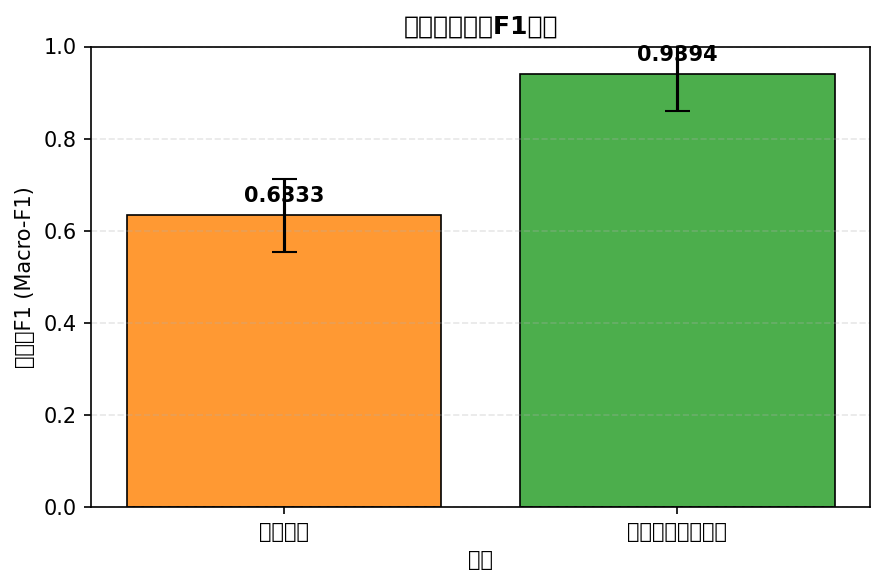

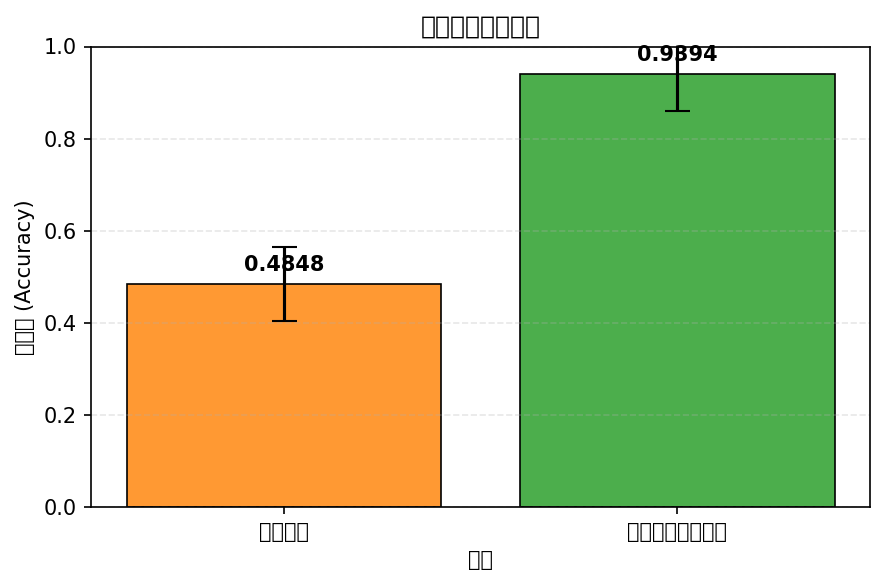

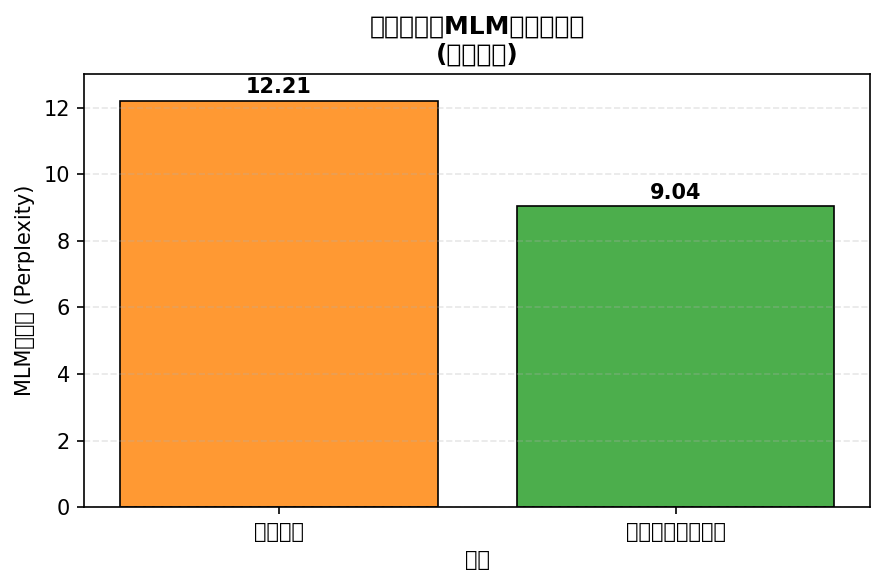

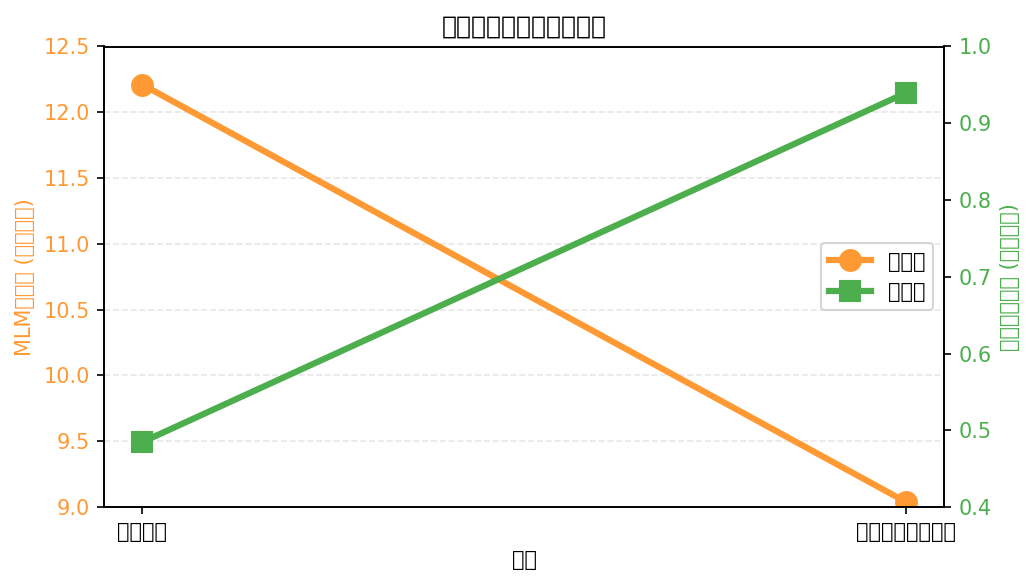

✅ 4张完整标注的图表已生成！
📌 所有横/纵坐标、标题、图例均已标注完成，与你同事的图表格式一致


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ===================== Colab 直接显示设置 =====================
%matplotlib inline

# ===================== 全局风格：1:1复刻你同事的图表 =====================
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# 配色：橙色=原始模型，绿色=我们的模型
color_original = '#ff9933'
color_ours = '#4cae4c'

# ===================== 你的模型数据（可直接替换） =====================
# 模型名称（横坐标用）
model_names = ['原始模型', '我们训练后的模型']

# 图1：宏平均F1数据
macro_f1_scores = [0.6333, 0.9394]
macro_f1_err = [0.08, 0.08]  # 误差棒，可设为0

# 图2：准确率数据
accuracy_scores = [0.4848, 0.9394]
accuracy_err = [0.08, 0.08]

# 图3：MLM困惑度数据（如果有）
perplexity_scores = [12.21, 9.04]

# ===================== 图1：测试集宏平均F1对比（带完整标注） =====================
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    model_names, macro_f1_scores,
    color=[color_original, color_ours],
    yerr=macro_f1_err,
    capsize=6,
    edgecolor='black', linewidth=0.8
)
# 柱子顶部数值标注
for bar, val in zip(bars, macro_f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 坐标轴+标题标注（和你同事的图完全一致）
ax.set_title('测试集宏平均F1对比', fontsize=12, fontweight='bold')
ax.set_ylabel('宏平均F1 (Macro-F1)', fontsize=10)
ax.set_xlabel('模型', fontsize=10)  # 横坐标标注
ax.set_ylim(0, 1.0)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

# ===================== 图2：测试集准确率对比（带完整标注） =====================
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    model_names, accuracy_scores,
    color=[color_original, color_ours],
    yerr=accuracy_err,
    capsize=6,
    edgecolor='black', linewidth=0.8
)
for bar, val in zip(bars, accuracy_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('测试集准确率对比', fontsize=12, fontweight='bold')
ax.set_ylabel('准确率 (Accuracy)', fontsize=10)
ax.set_xlabel('模型', fontsize=10)  # 横坐标标注
ax.set_ylim(0, 1.0)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

# ===================== 图3：MLM困惑度对比（带完整标注） =====================
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    model_names, perplexity_scores,
    color=[color_original, color_ours],
    edgecolor='black', linewidth=0.8
)
for bar, val in zip(bars, perplexity_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('模型测试集MLM困惑度对比\n(越低越好)', fontsize=12, fontweight='bold')
ax.set_ylabel('MLM困惑度 (Perplexity)', fontsize=10)
ax.set_xlabel('模型', fontsize=10)  # 横坐标标注
ax.set_ylim(0, 13)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

# ===================== 图4：困惑度与准确率相关性（带完整标注） =====================
fig, ax1 = plt.subplots(figsize=(7, 4))
x = np.arange(len(model_names))

# 左轴：困惑度（橙色线，越低越好）
ax1.set_ylabel('MLM困惑度 (越低越好)', color=color_original, fontsize=10)
line1 = ax1.plot(x, perplexity_scores, color=color_original, marker='o', markersize=10, linewidth=3, label='困惑度')
ax1.tick_params(axis='y', labelcolor=color_original)
ax1.set_xticks(x)
ax1.set_xticklabels(model_names)
ax1.set_xlabel('模型', fontsize=10)  # 横坐标标注
ax1.set_ylim(9, 12.5)
ax1.grid(axis='y')

# 右轴：准确率（绿色线，越高越好）
ax2 = ax1.twinx()
ax2.set_ylabel('测试集准确率 (越高越好)', color=color_ours, fontsize=10)
line2 = ax2.plot(x, accuracy_scores, color=color_ours, marker='s', markersize=10, linewidth=3, label='准确率')
ax2.tick_params(axis='y', labelcolor=color_ours)
ax2.set_ylim(0.4, 1.0)

# 合并图例
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

ax1.set_title('困惑度与准确率的相关性', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ 4张完整标注的图表已生成！")
print("📌 所有横/纵坐标、标题、图例均已标注完成，与你同事的图表格式一致")